In [17]:
import torch
from lofi_model import LofiModel
from dataset import MidiDataset, setup_datasets_and_dataloaders
import pretty_midi
import numpy as np
from config import *
from utils import visualize_latent_space
print(torch.__version__)
print(torch.version.cuda)

2.7.1+cu118
11.8


In [18]:
model = LofiModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model.load_state_dict(torch.load("./saved_models/best_models/mini dataset small model.pth"))
model.to(device)
model.eval()

LofiModel(
  (encoder): Encoder(
    (lstm): LSTM(76, 128, num_layers=2, batch_first=True, bidirectional=True)
    (fc_mean): Linear(in_features=256, out_features=64, bias=True)
    (fc_logvar): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(76, 128, num_layers=2, batch_first=True)
    (fc): Linear(in_features=128, out_features=76, bias=True)
  )
  (fc_latent_to_hidden): Linear(in_features=64, out_features=256, bias=True)
  (fc_latent_to_cell): Linear(in_features=64, out_features=256, bias=True)
)

## Latent visualization

In [19]:
# dataset_dir = r"C:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\dataset\transformed_dataset_smaller"
dataset_dir = r"C:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\dataset\golden_dataset\all_songs"

dataset = MidiDataset(dataset_dir, verbose=True)
train_dataloader, val_dataloader = setup_datasets_and_dataloaders(dataset_dir)
len(train_dataloader)

Setting up datasets and dataloaders...
Finished setting up datasets and dataloaders.



2


--- Visualising latent space ---
Saving plot to: latent_space.png



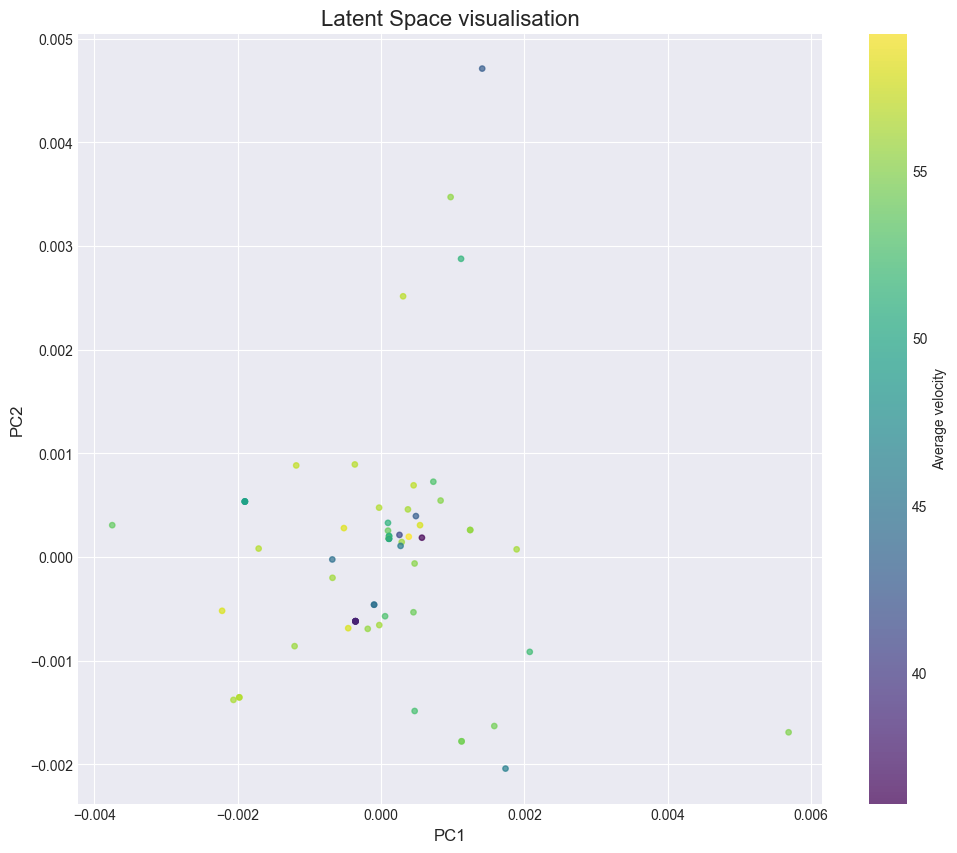

In [20]:
visualize_latent_space(model, train_dataloader)